In [1]:
#Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import statsmodels.api as sm
import math
from numpy import load
from moepy import lowess
from scipy.stats import linregress
from scipy.stats import norm
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import spearmanr
from Bio import SeqIO
from functools import reduce

In [2]:
#make plots illustrator friendly
mpl.rcParams.update({
    # Use Helvetica
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],

    # Keep text as true text in vector outputs
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,   
    "svg.fonttype": "none", 

    # Make sure we are not using LaTeX, which often causes per-character issues
    "text.usetex": False,
})

In [3]:
#Helper function
def load_and_process_replicate(file_path: str, replicate_id: int, metadata: pd.DataFrame) -> pd.DataFrame:
    """
    Load a single replicate file and perform all per-replicate processing:
    - Filter edit_string to contain the PAM-blocking edit
    - Keep only rows with exactly 2 commas in edit_string (only two real edits expected, one PAM-blocking and one SNC/indel)
    - Extract the middle element between commas and parse position (Pos)
    - Compute log2 ratios (post/pre, post/lib, lib)
    - Merge in metadata
    - Compute replicate-specific function score normalized to control insertions
    """

    # Load the data
    df = pd.read_csv(file_path, sep="\t")

    # Filter for intended PAM-blocking edits (note EDITB is artificially introduced in the fasta file to maintain compatibility with SGE pipeline)
    mask_edits = (
        df["edit_string"].str.contains(EDIT_A)
        & df["edit_string"].str.contains(EDIT_B)
    )
    df = df[mask_edits].copy()

    # Filter by number of commas (exactly 2), this removes indels, artefacts and sequencing errors
    df = df[df["edit_string"].str.count(",") == 2].copy()

    # Extract middle element between commas, this is the edit in the transcript
    df["Entry"] = df["edit_string"].apply(lambda x: x.split(",")[1])

    # Extract numeric position from middle element for registration
    df["Pos"] = df["Entry"].apply(lambda x: x.split("-")[0])
    df["Pos"] = pd.to_numeric(df["Pos"], errors="coerce")

    # Compute log2 ratios for plotting
    df["Log2_post_pre_ratio"] = np.log2(df["post_pre_ratio"].astype(float))
    df["Log2_post_lib_ratio"] = np.log2(df["post_lib_ratio"].astype(float))
    df["Log2_lib"] = np.log2(df["lib"].astype(float))

    # Merge metadata
    df = pd.merge(df, metadata, on="edit_string", how="left")

    # Replicate-specific function score
    # Normalise to median of control insertions in this replicate
    control_mask = df["Type"] == "control_insertion"
    control_median = df.loc[control_mask, "Log2_post_pre_ratio"].median()

    df[f"function_score_r{replicate_id}"] = df["Log2_post_pre_ratio"] - control_median

    #return dataframe
    return df

## Haploid data

In [4]:
# Input replicate files (edit counts from primary analysis)
replicate_files = {
    1: "../data/RNU42brL41.txt",
    2: "../data/RNU42brL42.txt",
    3: "../data/RNU42brL43.txt",
}

# Metadata file (oligo annotations)
metadata_file = "../metadata/251210_metadata_oligonucleotides.csv"

# Intended PAM-blocking edit-string filters
EDIT_A = "22-X-C"
EDIT_B = "200-X-A"

# QC thresholds variant representation in the final library under which it will be filtered out
PRE_FREQ_MIN = 0.0001
LIB_FREQ_MIN = 0.0001


#within transcripts position
POS_MIN = 49
POS_MAX = 199

In [5]:
# Load metadata
metadata = pd.read_csv(metadata_file)

# Process each replicate
rep_dfs = {}
for rep_id, filepath in replicate_files.items():
    rep_dfs[rep_id] = load_and_process_replicate(filepath, rep_id, metadata)

# Merge all replicates on edit_string
# Start with inner join of all replicates so we keep edits present in all replicates.
df_combined = reduce(
    lambda left, right: pd.merge(left, right, on="edit_string", how="inner"),
    [rep_dfs[1], rep_dfs[2], rep_dfs[3]],
)

# For convenience, take Pos and Type from replicate 1 (they are identical between each replicate)
df_combined["Pos"] = df_combined["Pos_x"]
df_combined["Type"] = df_combined["Type_x"]

# Compute mean values across replicates
# Mean log2 post/pre ratio across replicates
df_combined["Log2_post_pre_ratio_merged"] = df_combined[
    ["Log2_post_pre_ratio_x", "Log2_post_pre_ratio_y", "Log2_post_pre_ratio"]
].mean(axis=1, skipna=True)

# Mean log2 post/lib ratio across replicates
df_combined["Log2_post_lib_ratio_merged"] = df_combined[
    ["Log2_post_lib_ratio_x", "Log2_post_lib_ratio_y", "Log2_post_lib_ratio"]
].mean(axis=1, skipna=True)

# Mean pre-frequency across replicates
df_combined["pre_freq_merged"] = df_combined[
    ["pre_freq_x", "pre_freq_y", "pre_freq"]
].mean(axis=1, skipna=True)

# Mean pre read-count across replicates
df_combined["pre_avg"] = df_combined[
    ["pre_x", "pre_y", "pre"]
].mean(axis=1, skipna=True)

# Normalise merged function score to insertion controls
control_mask_combined = df_combined["Type"] == "control_insertion"
control_median_combined = df_combined.loc[
    control_mask_combined, "Log2_post_pre_ratio_merged"
].median()

df_combined["function_score"] = (
    df_combined["Log2_post_pre_ratio_merged"] - control_median_combined
)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
# Pre frequency filter to remove low-representation variants at day 4
df_combined = df_combined[df_combined["pre_freq_merged"].astype(float) > PRE_FREQ_MIN]

# Library frequency filter to remove low-representation variants in the library
df_combined = df_combined[df_combined["lib_freq"].astype(float) > LIB_FREQ_MIN]

# Position filter to subset to engineered variants inside of transcript position
df_combined = df_combined[
    (df_combined["Pos"] >= POS_MIN) & (df_combined["Pos"] <= POS_MAX)
]

In [7]:
# Rename read-count columns to explicit replicate/day labels
df_combined["d4_rep1_read_count"] = df_combined["pre_x"]
df_combined["d14_rep1_read_count"] = df_combined["post_x"]

df_combined["d4_rep2_read_count"] = df_combined["pre_y"]
df_combined["d14_rep2_read_count"] = df_combined["post_y"]

df_combined["d4_rep3_read_count"] = df_combined["pre"]
df_combined["d14_rep3_read_count"] = df_combined["post"]

df_combined["lib_read_count"] = df_combined["lib_x"]
df_combined["neg_read_count"] = df_combined["neg_x"]

# Columns to bring into the final table joined to metadata for downstream processing
columns_to_add = [
    "edit_string",
    "function_score",
    "function_score_r1",
    "function_score_r2",
    "function_score_r3",
    "d4_rep1_read_count",
    "d14_rep1_read_count",
    "d4_rep2_read_count",
    "d14_rep2_read_count",
    "d4_rep3_read_count",
    "d14_rep3_read_count",
    "lib_read_count",
    "neg_read_count",
    "pre_avg",
]

#subset to the selected columns
df_combined_sub = df_combined[columns_to_add]

# Final table: all oligos in metadata with functional scores/read counts where available
df_final = pd.merge(metadata, df_combined_sub, on="edit_string", how="left")

In [8]:
# Define neutral set of variant scores (insertion controls)
null_fss = df_final[df_final["Type"] == "control_insertion"]["function_score"]

# Calculate mean and standard deviation of the neutral variants
null_mean = null_fss.mean()
null_sd = null_fss.std()

# Get p-values by assuming experimental scores are drawn from this normal distribution
df_final["pvalues"] = norm.cdf(df_final["function_score"], loc=null_mean, scale=null_sd)

# Correct p-values for multiple hypothesis testing using the BH method
_, qvalues, _, _ = multipletests(df_final["pvalues"], method="fdr_bh")
df_final["qvalues"] = qvalues

#-log10 transformation
df_final["neg_log10_qvalues"] = -np.log10(df_final["qvalues"])

In [9]:
#plotting colors and hue order for different edit types
category_colors = {
    'SNV': '#414EA1',
    '1nt insertion': '#E12157',
    '1 nt insertion control': '#E5A337',
    'nmer insertion': '#E189F9',
    'deletion': '#59C5CA',

}
hue_order=['SNV','1 nt insertion control','nmer insertion', 'deletion', '1nt insertion']

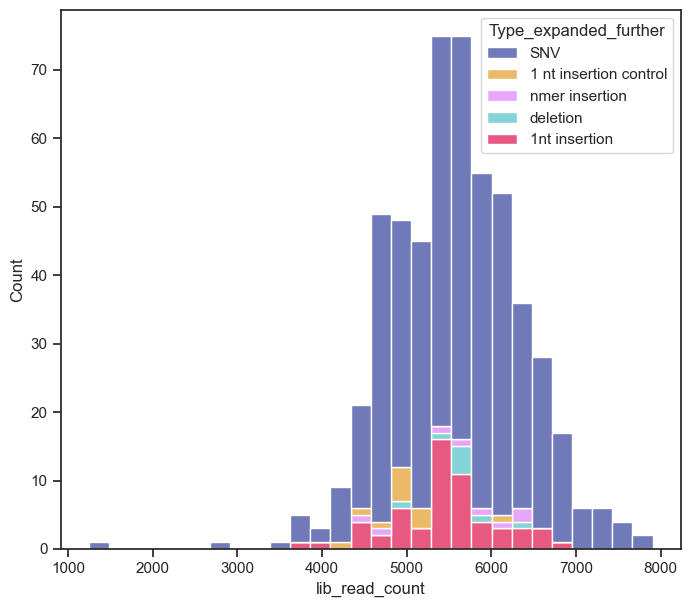

In [10]:
#Supplementary figure 1A, plotting library read counts
sns.set_theme(rc={'figure.figsize': (8, 7)})
sns.set_style("ticks")
sns.histplot(data=df_final, x="lib_read_count", hue="Type_expanded_further", multiple="stack", palette=category_colors,
        hue_order=hue_order)
plt.savefig("SFig_1A_library_read_counts.pdf")

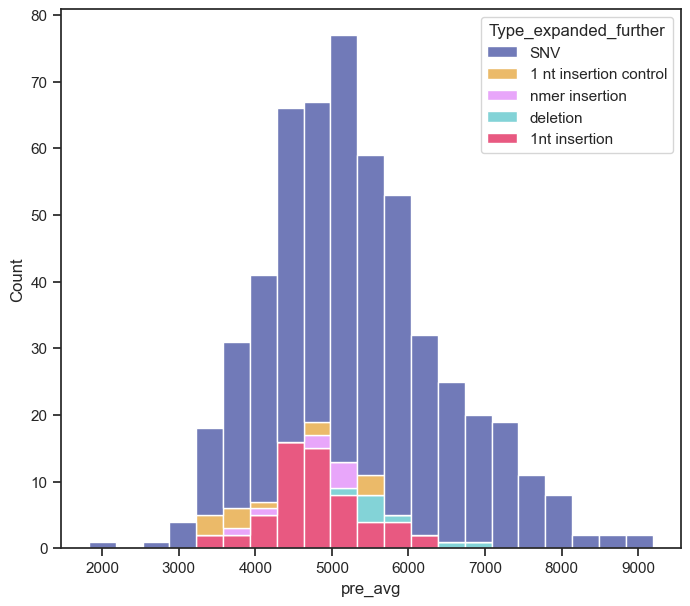

In [11]:
#Supplementary figure 1B, plotting day 4 ("pre") read counts
sns.histplot(data=df_final, x="pre_avg", hue="Type_expanded_further", multiple="stack", palette=category_colors,
        hue_order=hue_order)
plt.savefig("SFig_1B_D4_read_counts.pdf")

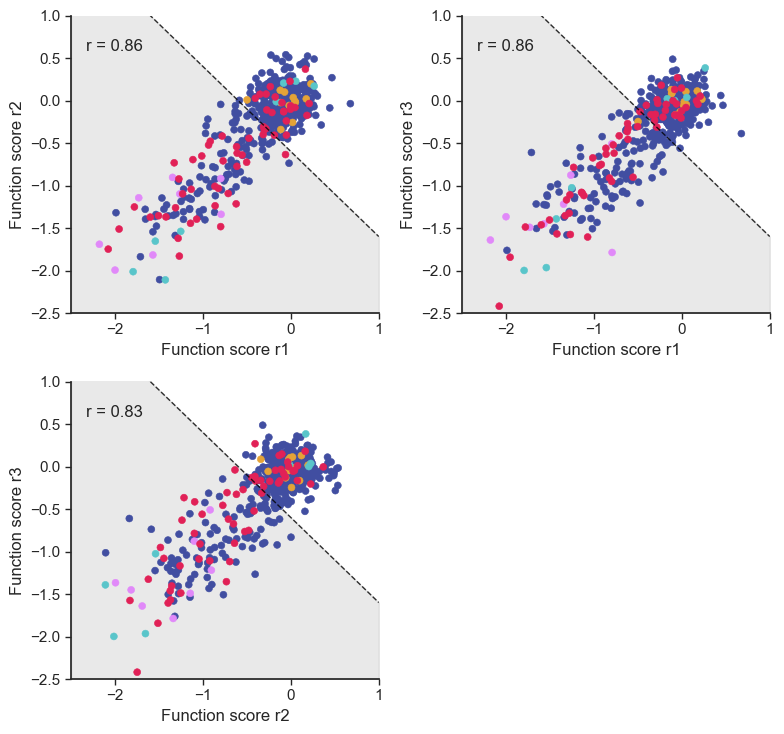

In [12]:
#Figure 1C/Sup Fig1C - Interreplicate scores
sns.set_theme(rc={'figure.figsize': (8, 7)})
sns.set_style("ticks")

#define pairs for plotting
pairs = [
    ("function_score_r1", "function_score_r2"),
    ("function_score_r1", "function_score_r3"),
    ("function_score_r2", "function_score_r3"),
]

#Set q-value threshold
thresh = -0.3
x_min, x_max = -2.5, 1
y_min, y_max = -2.5, 1
x_vals = np.linspace(x_min, x_max, 400)


fig, axes = plt.subplots(2, 2, figsize=(8, 7.5))
axes = axes.flatten()

for i, (xcol, ycol) in enumerate(pairs):
    ax = axes[i]

    #main inter-replicate plot
    sns.scatterplot(
        data=df_final.sort_values('Type_expanded_further', key=np.vectorize(hue_order.index)),
        x=xcol, y=ycol,
        hue="Type_expanded_further",
        palette=category_colors,
        hue_order=hue_order,
        s=25, edgecolor=None,
        legend=False,  # no legend
        ax=ax
    )

    #Shading q-value < 0.1
    ax.fill_between(x_vals, 2 * thresh - x_vals, y_min, color='darkgrey', alpha=0.25, zorder=0)
    ax.plot(x_vals, 2 * thresh - x_vals, ls="--", lw=1, color="black", alpha=0.8)

    #calculate correlation scores for display
    valid = df_final[[xcol, ycol]].dropna()
    r, _ = pearsonr(valid[xcol], valid[ycol])
    ax.text(0.05, 0.92, f"r = {r:.2f}", transform=ax.transAxes, ha="left", va="top")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel(xcol.replace("_", " ").replace("function score ", "Function score "))
    ax.set_ylabel(ycol.replace("_", " ").replace("function score ", "Function score "))
    ax.tick_params(axis='both', length=4, width=1, direction='out')

# Hide the unused 4th subplot
fig.delaxes(axes[-1])

sns.despine()
plt.tight_layout()
plt.savefig("Fig1C_interreplicate_correlation.pdf", dpi=300)
plt.show()

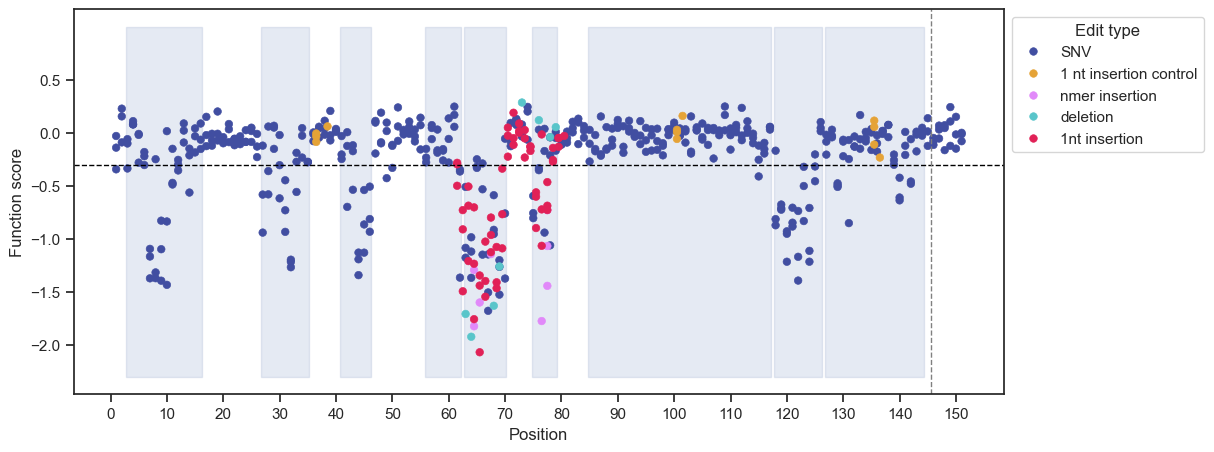

In [13]:
#Figure 1D - positional plot
sns.set_theme(rc={'figure.figsize':(12,5)})
sns.set_style("ticks")


# Add structure detailed shading
plt.fill_between([2.75,16.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([26.75,35.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([40.75,46.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([55.75,62.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([62.75,70.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([74.75,79.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([84.75,117.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([117.75,126.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([126.75,144.25], -2.3, 1, color='#8098c4', alpha=0.2)

#Main position plot
ax=sns.scatterplot(data=df_final.sort_values('Type_expanded_further',key=np.vectorize(hue_order.index)), x="plot_position", y="function_score",  
                hue="Type_expanded_further", palette=category_colors,hue_order=hue_order,edgecolor=None,s=30)

ax.set_xticks(np.arange(int(df_final["plot_position"].min()) - 1, int(df_final["plot_position"].max()) + 1, 5))

# Add dashed horizontal line at y=-0.3 for q=0.01
ax.axhline(y=-0.3, color='black', linestyle='dashed', linewidth=1)  # Horizontal intercept

# Add dashed vertical lines at x=145.5 to mark end of transcript
ax.axvline(x=145.5, color='grey', linestyle='dashed', linewidth=1)  # Vertical intercept

plt.ylabel("Function score")
plt.xlabel("Position")
plt.legend(title='Edit type')

plt.xticks(np.arange(0,151,10))
plt.yticks(np.arange(-2,1,0.5))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.savefig("Fig_1D_SGE_RNU4_2_position plot.pdf")

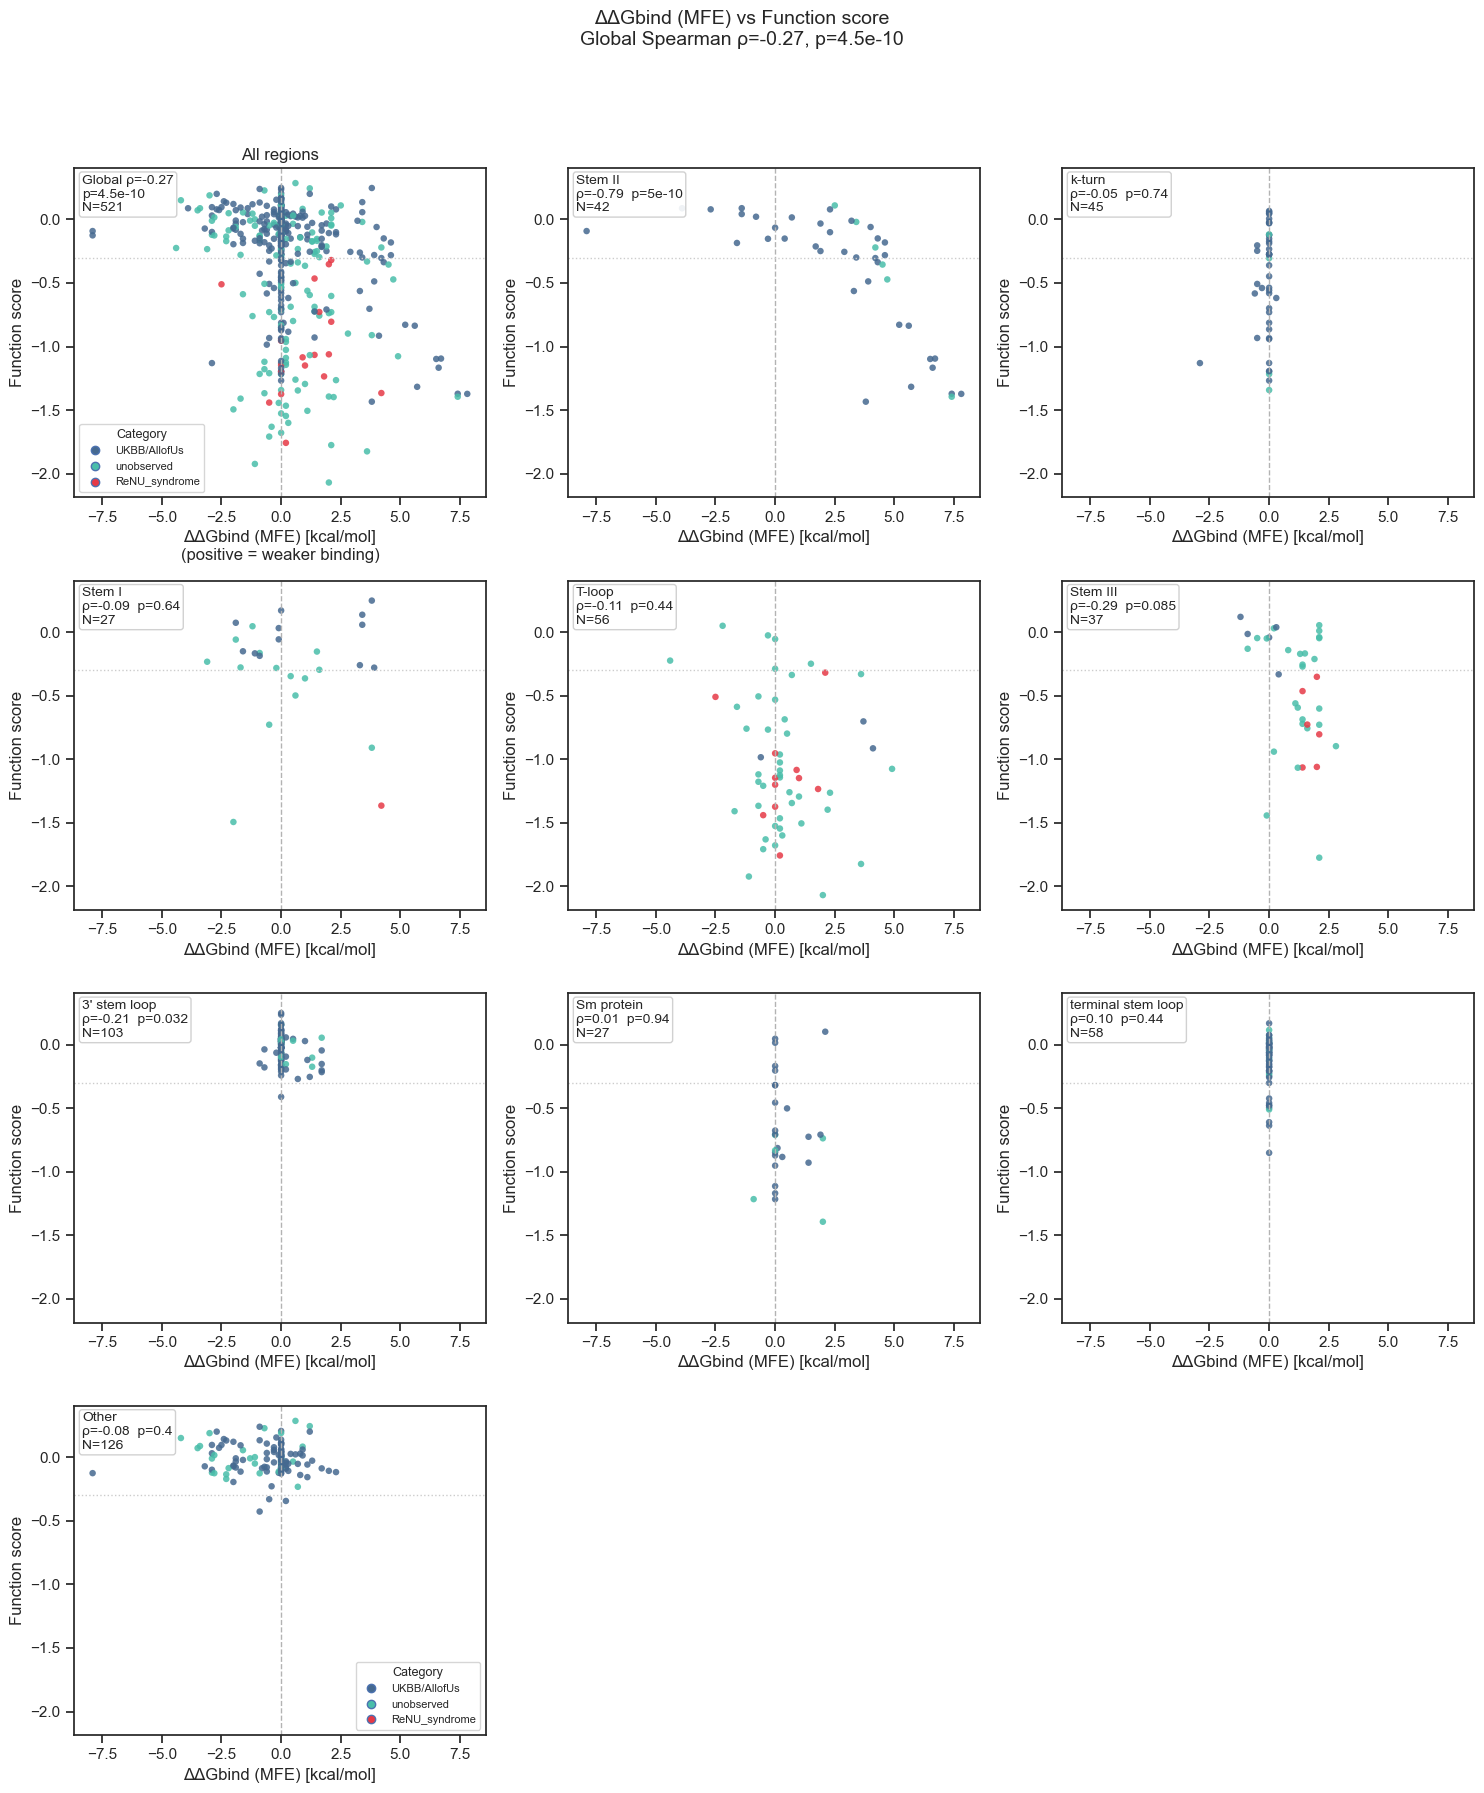

In [14]:
#Supplementary Figure 3 - ViennaRNA ddGbind plotting

# defined region mapping withing the transcript
def assign_region(pos: int) -> str:
    if 3 <= pos <= 16:
        return "Stem II"
    elif ((27 <= pos <= 35) | (41 <= pos <= 46)):
        return "k-turn"
    elif 56 <= pos < 62.25:
        return "Stem I"
    elif 62.75 <= pos <= 70.25:
        return "T-loop"
    elif 74.75 <= pos <= 79.25:
        return "Stem III"
    elif 85 <= pos <= 117:
        return "3' stem loop"
    elif 118 <= pos <= 126:
        return "Sm protein"
    elif 127 <= pos <= 144:
        return "terminal stem loop"
    else:
        return "Other"

# assign regions to the dataframe
dfp = df_final.dropna(subset=["ddG_bind_mfe", "function_score", "plot_position"]).copy()
dfp["plot_position"] = dfp["plot_position"].astype(int)
dfp["region"] = dfp["plot_position"].apply(assign_region)

# order for subplots (only keep those present)
region_order = ["Stem II", "k-turn", "Stem I", "T-loop", "Stem III", "3' stem loop", "Sm protein", "terminal stem loop", "Other"]
regions_present = [r for r in region_order if r in dfp["region"].unique()]

# global axis limits for consistent scales
x = dfp["ddG_bind_mfe"].to_numpy(float)
y = dfp["function_score"].to_numpy(float)
xpad = (np.nanmax(x) - np.nanmin(x)) * 0.05 if np.isfinite(x).all() else 0.5
ypad = (np.nanmax(y) - np.nanmin(y)) * 0.05 if np.isfinite(y).all() else 0.1
xlim = (np.nanmin(x) - xpad, np.nanmax(x) + xpad)
ylim = (np.nanmin(y) - ypad, np.nanmax(y) + ypad)

# global Spearman for all points 
global_rho, global_p = (np.nan, np.nan)
if (
    dfp["ddG_bind_mfe"].notna().sum() >= 3
    and dfp["function_score"].notna().sum() >= 3
):
    global_rho, global_p = spearmanr(dfp["ddG_bind_mfe"], dfp["function_score"])

# figure layout: 4 rows x 2 columns = 8 panels
nrows, ncols = 4, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), squeeze=False)
axes = axes.flatten()

# color maps 
# region colors (for the global "all regions" panel)
region_palette = {
    "Stem I": "#1b9e77",
    "Stem II": "#d95f02",
    "Stem III": "#7570b3",
    "T-loop": "#e7298a",
    "3' stem loops": "#66a61e",
    "k-turn": "#a6761d",
    "Sm protein" : "#8d00af",
    "terminal stem loop" : "#6b700b",
    "Other": "#666666",
}

# category colors (for the per-region zoomed panels)
category_palette = {
    "UKBB/AllofUs": "#456990",
    "unobserved": "#49beaa",
    "ReNU_syndrome": "#e63946",
}

# GLOBAL PANEL: all regions in one plot
ax_all = axes[0]

# map categories to colours
global_colors = dfp["category"].map(category_palette).fillna("#999999").to_numpy()

ax_all.scatter(
    dfp["ddG_bind_mfe"].to_numpy(float),
    dfp["function_score"].to_numpy(float),
    s=22, alpha=0.85, edgecolor="none",
    c=global_colors,
)

# guide lines
ax_all.axvline(0, ls="--", lw=1, color="0.7")
ax_all.axhline(-0.3, ls=":",  lw=1, color="0.8")

ax_all.set_xlim(*xlim)
ax_all.set_ylim(*ylim)
ax_all.set_xlabel("ΔΔGbind (MFE) [kcal/mol]\n(positive = weaker binding)")
ax_all.set_ylabel("Function score")
ax_all.set_title("All regions", fontsize=12)

# global stats annotation on the global panel
stats_str = (
    f"Global ρ={global_rho:.2f}\np={global_p:.2g}\nN={len(dfp)}"
    if np.isfinite(global_rho)
    else f"Global ρ=NA\np=NA\nN={len(dfp)}"
)

ax_all.text(
    0.02, 0.98, stats_str,
    transform=ax_all.transAxes,
    va="top", ha="left", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.8", alpha=0.9),
)

# add category legend to the global panel
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='none', markersize=6,
           markerfacecolor=color, label=cat)
    for cat, color in category_palette.items()
]
ax_all.legend(handles=legend_handles, title="Category",
              fontsize=8, title_fontsize=9, loc="best", frameon=True)

# PER-REGION PANELS: zoomed, colored by category
for idx, region in enumerate(regions_present, start=1):  # start at 1 because 0 is global panel
    if idx >= len(axes):
        break 

    ax = axes[idx]
    sub = dfp[dfp["region"] == region]

    # map categories to colors; unknown categories get a default grey
    colors = sub["category"].map(category_palette).fillna("#999999").to_numpy()

    ax.scatter(
        sub["ddG_bind_mfe"].to_numpy(float),
        sub["function_score"].to_numpy(float),
        s=22, alpha=0.85, edgecolor="none",
        c=colors,
    )

    # guide lines
    ax.axvline(0, ls="--", lw=1, color="0.7")
    ax.axhline(-0.3, ls=":",  lw=1, color="0.8")

    # per-region Spearman
    rho, p = (np.nan, np.nan)
    if len(sub) >= 3 and sub["ddG_bind_mfe"].notna().sum() >= 3 and sub["function_score"].notna().sum() >= 3:
        rho, p = spearmanr(sub["ddG_bind_mfe"], sub["function_score"])

    n_points = len(sub)
    if np.isfinite(rho):
        stats_str = f"{region}\nρ={rho:.2f}  p={p:.2g}\nN={n_points}"
    else:
        stats_str = f"{region}\nρ=NA  p=NA\nN={n_points}"

    # format text for stats
    ax.text(
        0.02, 0.98,
        stats_str,
        transform=ax.transAxes, va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="0.8", alpha=0.9)
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("ΔΔGbind (MFE) [kcal/mol]")
    ax.set_ylabel("Function score")

# add a category legend in the last plot
last_used_axis_index = 1 + len(regions_present) - 1
if last_used_axis_index < len(axes):
    ax_legend = axes[last_used_axis_index]
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='none', markersize=6,
               markerfacecolor=color, label=cat)
        for cat, color in category_palette.items()
    ]
    ax_legend.legend(
        handles=legend_handles, title="Category",
        fontsize=8, title_fontsize=9, loc="lower right", frameon=True
    )

# remove any completely unused axes beyond global + regions
used_axes = 1 + len(regions_present)
for j in range(used_axes, nrows*ncols):
    fig.delaxes(axes[j])

# title with global info (optional, global stats already on global panel)
if np.isfinite(global_rho):
    sup_title = (
        "ΔΔGbind (MFE) vs Function score\n"
        f"Global Spearman ρ={global_rho:.2f}, p={global_p:.2g}"
    )
else:
    sup_title = "ΔΔGbind (MFE) vs Function score"

fig.suptitle(sup_title, y=0.995, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig("SFig3_ddGbindMFE_vs_function_by_region.pdf")
plt.show()

In [15]:
#subset to within-transcripts SNVs only for ROC_AUC analysis
df_merged=df_final[(df_final["category"]=='ReNU_syndrome')|(df_final["category"]=='UKBB/AllofUs')|(df_final["category"]=='unobserved')]
df_merged_SNV=df_merged[df_merged["Type"]=="SNV"]

/var/folders/wc/ytgn09293yd8b79m53bzfgph0000gp/T/ipykernel_27414/4258296777.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_SNV["function_score"] = pd.to_numeric(df_merged_SNV["function_score"], errors="coerce")
/var/folders/wc/ytgn09293yd8b79m53bzfgph0000gp/T/ipykernel_27414/4258296777.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_SNV["CADD_score"] = pd.to_numeric(df_merged_SNV["CADD_score"], errors="coerce")
/var/folders/wc/ytgn09293yd8b79m53bzfgph0000gp/T/ipykernel_27414/425

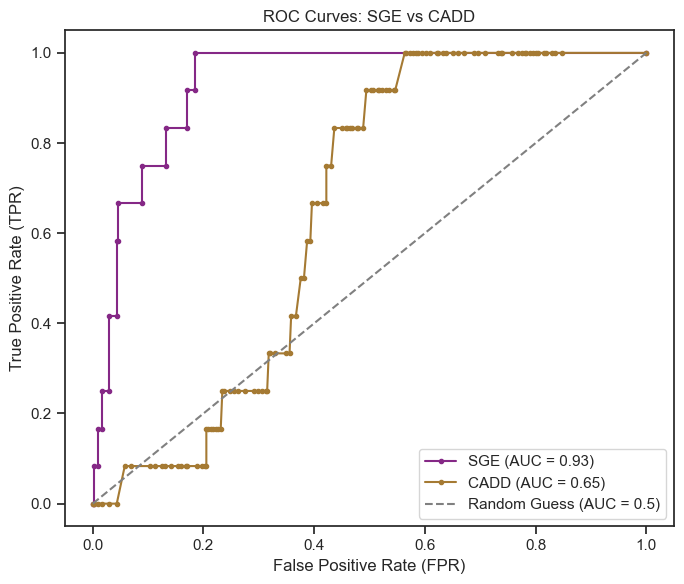

In [16]:
#Figure 2C - ROC-AUC curve
# Ensure scores are numeric
df_merged_SNV["function_score"] = pd.to_numeric(df_merged_SNV["function_score"], errors="coerce")
df_merged_SNV["CADD_score"] = pd.to_numeric(df_merged_SNV["CADD_score"], errors="coerce")

# Define labels: 1 = deleterious ReNU, 0 = neutral (seen in population)
df_merged_SNV["Label"] = np.where(
    df_merged_SNV["category"] == "ReNU_syndrome", 1,
    np.where(df_merged_SNV["category"] == "UKBB/AllofUs", 0, np.nan)
)

# Prepare for SGE ROC
df_sge = df_merged_SNV.dropna(subset=["Label", "function_score"]).copy()
df_sge["Label"] = df_sge["Label"].astype(int)

#calculate false and true positive rates
fpr_sge, tpr_sge, _ = roc_curve(df_sge["Label"], -df_sge["function_score"])  # Negate SGE score 
auc_sge = roc_auc_score(df_sge["Label"], -df_sge["function_score"])

# Prepare for CADD ROC
df_cadd = df_merged_SNV.dropna(subset=["Label", "CADD_score"]).copy()
df_cadd["Label"] = df_cadd["Label"].astype(int)
fpr_cadd, tpr_cadd, _ = roc_curve(df_cadd["Label"], df_cadd["CADD_score"])
auc_cadd = roc_auc_score(df_cadd["Label"], df_cadd["CADD_score"])

# Plot both ROC-AUCcurves
plt.figure(figsize=(7, 6))

plt.plot(fpr_sge, tpr_sge, label=f'SGE (AUC = {auc_sge:.2f})', color="#852886", marker='.')
plt.plot(fpr_cadd, tpr_cadd, label=f'CADD (AUC = {auc_cadd:.2f})', color="#A57A33", marker='.')

# Add diagonal line for random guess
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves: SGE vs CADD")
plt.legend()

# Save the combined ROC plot
plt.tight_layout()
plt.savefig("Fig2C_combined_ROC_SGE_CADD_ROC_AUC.pdf", dpi=300)
plt.show()

/var/folders/wc/ytgn09293yd8b79m53bzfgph0000gp/T/ipykernel_27414/1595457049.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_SNV["ddG_bind_mfe"] = pd.to_numeric(df_merged_SNV["ddG_bind_mfe"], errors="coerce")


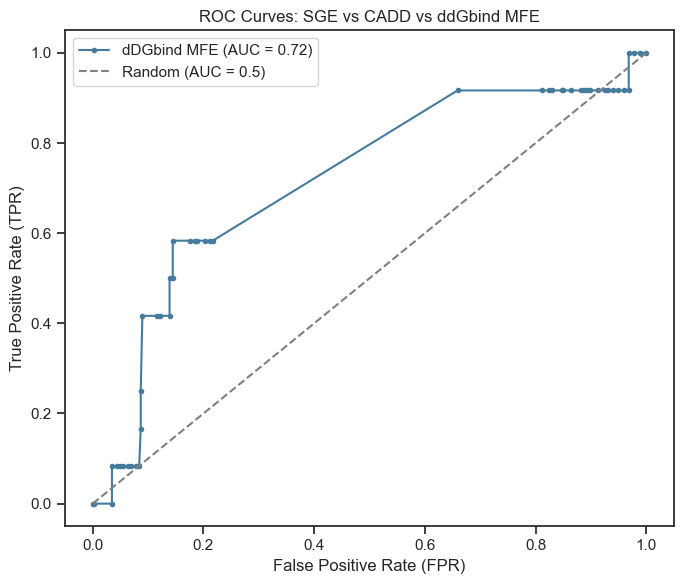

In [17]:
#Supplementary Figure 3B - ROC-AUC curve for ddGbind_mfe

# Ensure numeric types
df_merged_SNV["ddG_bind_mfe"] = pd.to_numeric(df_merged_SNV["ddG_bind_mfe"], errors="coerce")

# Prepare for ddGbind_roc
df_ddg = df_merged_SNV.dropna(subset=["Label", "ddG_bind_mfe"]).copy()
df_ddg["Label"] = df_ddg["Label"].astype(int)
fpr_ddg, tpr_ddg, _ = roc_curve(df_ddg["Label"], df_ddg["ddG_bind_mfe"])
auc_ddg = roc_auc_score(df_ddg["Label"], df_ddg["ddG_bind_mfe"])

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr_ddg, tpr_ddg,
         label=f'dDGbind MFE (AUC = {auc_ddg:.2f})',
         color="#457b9d", marker='.')   # ← NEW COLOUR

# Diagonal reference
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.5)')

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves: SGE vs CADD vs ddGbind MFE")
plt.legend()

plt.tight_layout()
plt.savefig("SFig_3B_combined_ROC_SGE_CADD_dDGbindMFE.pdf", dpi=300)
plt.show()

Maximum AUC in grid: 1.00000


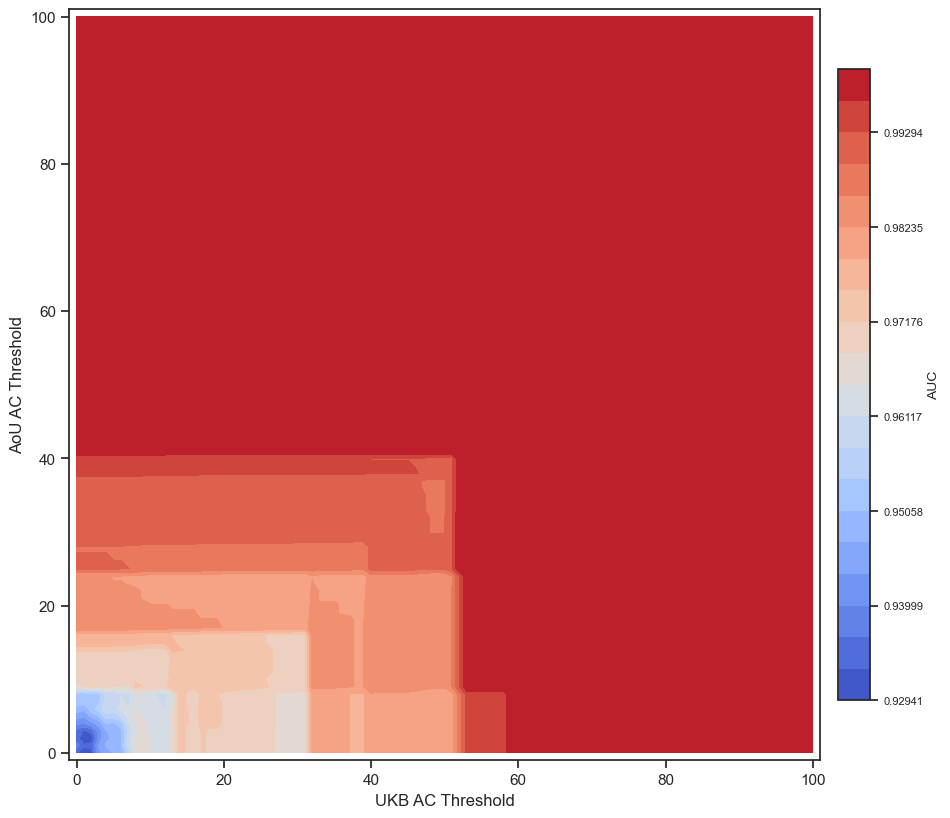

In [22]:
#Supplementary figure 2 - allele count thresholds
# Work on a copy to avoid SettingWithCopyWarning
df_merged_SNV = df_merged_SNV.copy()

# 1) Preprocessing
df_merged_SNV.loc[:, "AoU_AC"] = pd.to_numeric(df_merged_SNV["AoU_AC"], errors="coerce").fillna(0)
df_merged_SNV.loc[:, "UKBiobank_AC"] = pd.to_numeric(df_merged_SNV["UKBiobank_AC"], errors="coerce").fillna(0)

aou_thresholds = np.arange(0, 101, 1)
ukb_thresholds = np.arange(0, 101, 1)

auc_results = []
num_entries = []

# 2) Compute AUC + Num_Entries for each threshold pair
for aou_thresh in aou_thresholds:
    for ukb_thresh in ukb_thresholds:

        filtered_df = df_merged_SNV[
            ((df_merged_SNV["category"] == "ReNU_syndrome") |
             ((df_merged_SNV["category"] == "UKBB/AllofUs") &
              (df_merged_SNV["UKBiobank_AC"] >= ukb_thresh) &
              (df_merged_SNV["AoU_AC"] >= aou_thresh)))
        ].copy()

        # number retained in UKBB/AllofUs
        num_entries.append((
            aou_thresh,
            ukb_thresh,
            len(filtered_df[filtered_df["category"] == "UKBB/AllofUs"])
        ))

        if len(filtered_df) > 1:
            filtered_df.loc[:, "Label"] = np.where(
                filtered_df["category"] == "ReNU_syndrome", 1, 0
            )
            y_true = filtered_df["Label"]
            y_scores = -filtered_df["function_score"]
            auc_score = roc_auc_score(y_true, y_scores)
        else:
            auc_score = np.nan

        auc_results.append((aou_thresh, ukb_thresh, auc_score))

# 3) Merge into single DataFrame
auc_df = pd.DataFrame(
    auc_results,
    columns=["AoU_AC_Threshold", "UKBiobank_AC_Threshold", "AUC"]
)
num_df = pd.DataFrame(
    num_entries,
    columns=["AoU_AC_Threshold", "UKBiobank_AC_Threshold", "Num_Entries"]
)

merged_df = pd.merge(
    auc_df, num_df,
    on=["AoU_AC_Threshold", "UKBiobank_AC_Threshold"]
)

# 4) Build grids for contour plotting
x_vals = np.sort(merged_df["UKBiobank_AC_Threshold"].unique())
y_vals = np.sort(merged_df["AoU_AC_Threshold"].unique())

AUC_grid = merged_df.pivot(
    index="AoU_AC_Threshold",
    columns="UKBiobank_AC_Threshold",
    values="AUC"
).loc[y_vals, x_vals].values

N_grid = merged_df.pivot(
    index="AoU_AC_Threshold",
    columns="UKBiobank_AC_Threshold",
    values="Num_Entries"
).loc[y_vals, x_vals].values

#Print max AUC
auc_max = np.nanmax(AUC_grid)
print(f"Maximum AUC in grid: {auc_max:.5f}")

# 5) Plot: AUC filled contours + Num_Entries contour lines + dashed high-AUC boundary
fig, ax = plt.subplots(figsize=(10, 9))

# Filled contours for AUC – use actual data range
vmin = np.nanmin(AUC_grid)
levels_auc = np.linspace(vmin, auc_max, 21)

cf = ax.contourf(
    x_vals,
    y_vals,
    AUC_grid,
    levels=levels_auc,
    cmap="coolwarm",
    vmin=vmin,
    vmax=auc_max
)

# Axis labels and layout
ax.set_xlabel("UKB AC Threshold")
ax.set_ylabel("AoU AC Threshold")

ax.set_xlim(-1, 101)
ax.set_ylim(-1, 101)
ax.set_aspect("equal")

# Compact colorbar
cbar = fig.colorbar(cf, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("AUC", fontsize=10)
cbar.ax.tick_params(labelsize=8)


plt.tight_layout()
plt.savefig("SFig2_AUC_for_UKBB_AoU_AC_thresholds.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
# Calulating min & average score per position calculation for SNVs
df_snv_stats = (
    df_merged_SNV[df_merged_SNV["Type_expanded_further"].str.contains("SNV", na=False)]
    .groupby("plot_position", as_index=False)
    .agg(
        min_score=("function_score", "min"),
        avg_score=("function_score", "mean")
    )
)

# Define the categorization based on the *minimum* function_score value
def categorize_function_score(score):
    if score < -0.9:
        return "high"
    elif -1 <= score < -0.3:
        return "moderate"
    else:
        return "neutral"

df_snv_stats["category"] = df_snv_stats["min_score"].apply(categorize_function_score)

#save the dataframe
df_snv_stats.to_csv("SNV_min_and_avg_scores_per_position.csv", index=False)


## Diploid data

In [28]:
# Input replicate files (edit counts)
replicate_files = {
    1: "../data/RNU42rL41_dip.txt",
    2: "../data/RNU42rL42_dip.txt",
    3: "../data/RNU42rL43_dip.txt",
}

In [29]:
#Filtering steps as with the haploid data
# Load metadata
metadata = pd.read_csv(metadata_file)

# Process each replicate
rep_dfs = {}
for rep_id, filepath in replicate_files.items():
    rep_dfs[rep_id] = load_and_process_replicate(filepath, rep_id, metadata)

# Merge all replicates on edit_string
# Start with inner join of all replicates so we keep edits present in all replicates.
df_combined = reduce(
    lambda left, right: pd.merge(left, right, on="edit_string", how="inner"),
    [rep_dfs[1], rep_dfs[2], rep_dfs[3]],
)

# For convenience, take Pos and Type from replicate 1 (they should be identical)
df_combined["Pos"] = df_combined["Pos_x"]
df_combined["Type"] = df_combined["Type_x"]

# Compute mean values across replicates
# Mean log2 post/pre ratio across replicates
df_combined["Log2_post_pre_ratio_merged"] = df_combined[
    ["Log2_post_pre_ratio_x", "Log2_post_pre_ratio_y", "Log2_post_pre_ratio"]
].mean(axis=1, skipna=True)

# Mean log2 post/lib ratio across replicates
df_combined["Log2_post_lib_ratio_merged"] = df_combined[
    ["Log2_post_lib_ratio_x", "Log2_post_lib_ratio_y", "Log2_post_lib_ratio"]
].mean(axis=1, skipna=True)

# Mean pre-frequency across replicates
df_combined["pre_freq_merged"] = df_combined[
    ["pre_freq_x", "pre_freq_y", "pre_freq"]
].mean(axis=1, skipna=True)

# Mean pre read-count across replicates
df_combined["pre_avg"] = df_combined[
    ["pre_x", "pre_y", "pre"]
].mean(axis=1, skipna=True)

# Normalise merged function score to insertion controls
control_mask_combined = df_combined["Type"] == "control_insertion"
control_median_combined = df_combined.loc[
    control_mask_combined, "Log2_post_pre_ratio_merged"
].median()

df_combined["function_score"] = (
    df_combined["Log2_post_pre_ratio_merged"] - control_median_combined
)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [30]:
# Pre frequency filter
df_combined = df_combined[df_combined["pre_freq_merged"].astype(float) > PRE_FREQ_MIN]

# Library frequency filter
df_combined = df_combined[df_combined["lib_freq"].astype(float) > LIB_FREQ_MIN]

# Position filter
df_combined = df_combined[
    (df_combined["Pos"] >= POS_MIN) & (df_combined["Pos"] <= POS_MAX)
]

In [31]:
# Rename read-count columns to explicit replicate/day labels
df_combined["d4_rep1_read_count"] = df_combined["pre_x"]
df_combined["d14_rep1_read_count"] = df_combined["post_x"]

df_combined["d4_rep2_read_count"] = df_combined["pre_y"]
df_combined["d14_rep2_read_count"] = df_combined["post_y"]

df_combined["d4_rep3_read_count"] = df_combined["pre"]
df_combined["d14_rep3_read_count"] = df_combined["post"]

df_combined["lib_read_count"] = df_combined["lib_x"]
df_combined["neg_read_count"] = df_combined["neg_x"]

# Columns to bring into the final table joined to metadata
columns_to_add = [
    "edit_string",
    "function_score",
    "function_score_r1",
    "function_score_r2",
    "function_score_r3",
    "d4_rep1_read_count",
    "d14_rep1_read_count",
    "d4_rep2_read_count",
    "d14_rep2_read_count",
    "d4_rep3_read_count",
    "d14_rep3_read_count",
    "lib_read_count",
    "neg_read_count",
    "pre_avg",
]

df_combined_sub = df_combined[columns_to_add]
df_final_dip=pd.merge(metadata, df_combined_sub, on='edit_string', how='left')

In [32]:
# Define neutral set of variant scores (insertion controls)
null_fss = df_final_dip[df_final_dip["Type"] == "control_insertion"]["function_score"]

# Calculate mean and standard deviation of the neutral variants
null_mean = null_fss.mean()
null_sd = null_fss.std()

# Get p-values by assuming experimental scores are drawn from this normal distribution
df_final_dip["pvalues"] = norm.cdf(df_final_dip["function_score"], loc=null_mean, scale=null_sd)

# Correct p-values for multiple hypothesis testing using the BH method
_, qvalues, _, _ = multipletests(df_final_dip["pvalues"], method="fdr_bh")
df_final_dip["qvalues"] = qvalues

#-log10 transformation
df_final_dip["neg_log10_qvalues"] = -np.log10(df_final_dip["qvalues"])

In [33]:
# Columns to copy from diploid into the pre-existing haploid dataframe
columns_to_copy = [
    "function_score", "function_score_r1", "function_score_r2", "function_score_r3",
    "d4_rep1_read_count", "d14_rep1_read_count", 
    "d4_rep2_read_count", "d14_rep2_read_count", 
    "d4_rep3_read_count", "d14_rep3_read_count", "pvalues", "qvalues", "neg_log10_qvalues"
]

# Keep 'edit_string' and the columns of interest from diploid
dip_subset = df_final_dip[["edit_string"] + columns_to_copy].copy()

# Rename diploid columns with _dip suffix (except 'edit_string')
dip_subset = dip_subset.rename(columns={col: f"{col}_dip" for col in columns_to_copy})

# Merge on 'edit_string'
merged_df = df_final.merge(dip_subset, on="edit_string", how="left")

# Save final dataframe to a new CSV
merged_df.to_csv("20251211_RNU4_2_merged.csv", index=False)

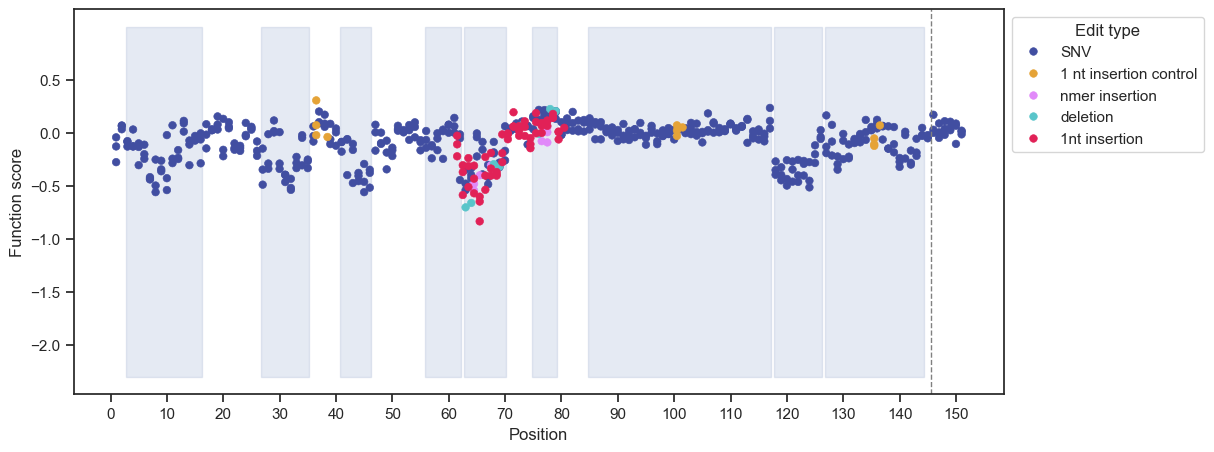

In [34]:
#Suppplementary Figure 7A - positional plot for diploid data, as for Figure 1A

sns.set_theme(rc={'figure.figsize':(12,5)})
sns.set_style("ticks")


# Add structure details
plt.fill_between([2.75,16.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([26.75,35.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([40.75,46.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([55.75,62.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([62.75,70.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([74.75,79.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([84.75,117.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([117.75,126.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([126.75,144.25], -2.3, 1, color='#8098c4', alpha=0.2)

ax=sns.scatterplot(data=merged_df.sort_values('Type_expanded_further',key=np.vectorize(hue_order.index)), x="plot_position", y="function_score_dip",  
                hue="Type_expanded_further", palette=category_colors,hue_order=hue_order,edgecolor=None,s=30)

ax.set_xticks(np.arange(int(df_final["position_oligonucleotide"].min()) - 1, int(df_final["position_oligonucleotide"].max()) + 1, 5))


# Add dashed vertical lines at x=145.5 to mark end of transcript
ax.axvline(x=145.5, color='grey', linestyle='dashed', linewidth=1)  # Vertical intercept

plt.ylabel("Function score")
plt.xlabel("Position")
plt.legend(title='Edit type')

plt.xticks(np.arange(0,151,10))
plt.yticks(np.arange(-2,1,0.5))
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.savefig("SFig_7A_diploid_positional_plot.pdf")

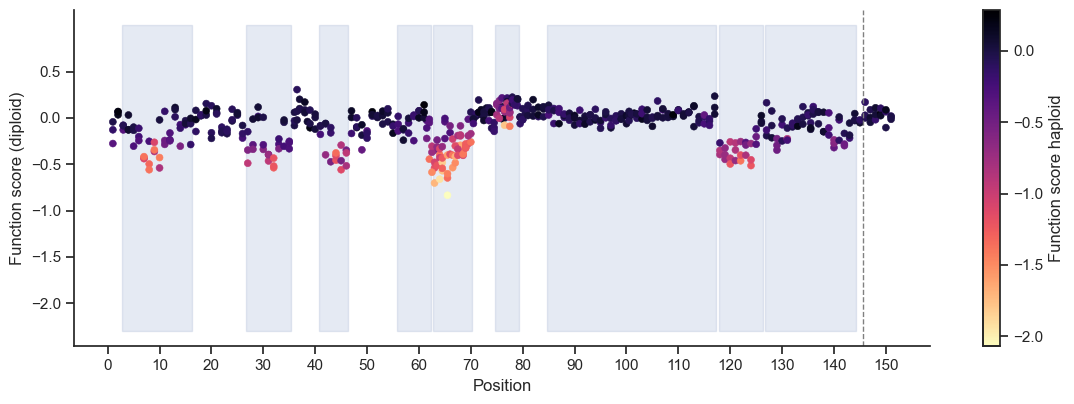

In [35]:
#Suppplementary Figure 7B, positional function score diploid versus haploid
sns.set_theme(rc={'figure.figsize': (11.7, 4.2)})
sns.set_style("ticks")

# Add structure details
plt.fill_between([2.75,16.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([26.75,35.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([40.75,46.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([55.75,62.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([62.75,70.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([74.75,79.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([84.75,117.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([117.75,126.25], -2.3, 1, color='#8098c4', alpha=0.2)
plt.fill_between([126.75,144.25], -2.3, 1, color='#8098c4', alpha=0.2)

#plot revers color map, brighter colour indicates low haploid score
ax = sns.scatterplot(data=merged_df,x="plot_position",y="function_score_dip",hue="function_score",palette="magma_r",edgecolor=None,legend=False,s=25)

ax.set_xticks(np.arange(int(df_final["plot_position"].min()) - 1, int(df_final["plot_position"].max()) + 1, 5))


# Add dashed vertical lines at x=145.5 to mark end of transcript
ax.axvline(x=145.5, color='grey', linestyle='dashed', linewidth=1)  # Vertical intercept


ax.set_ylabel("Function score (diploid)")
ax.set_xlabel("Position")

plt.xticks(np.arange(0,151,10))
plt.yticks(np.arange(-2,1,0.5))

#plot colorbar
vmin = np.nanmin(df_final["function_score"])
vmax = np.nanmax(df_final["function_score"])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=mpl.colormaps['magma_r'], norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Function score haploid")

sns.despine()
plt.tight_layout()
plt.savefig("SFig_7B_gene_position_diploid_and_haploid_scores.pdf", dpi=300)
plt.show()

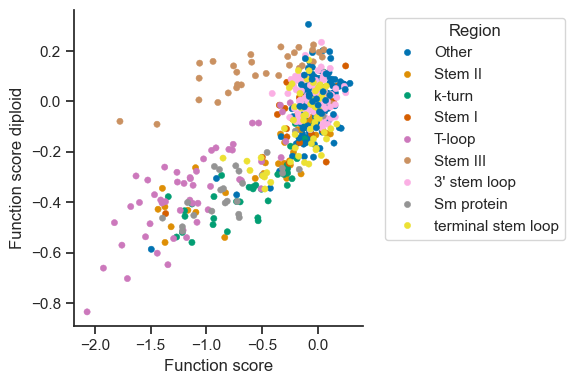

In [36]:
#Supplementary Figure 7C - haploid versus diploid score per region
#Plot settings
sns.set_theme(rc={'figure.figsize': (6, 4)})
sns.set_style("ticks")

# region mapping
def assign_region(pos: int) -> str:
    if 3 <= pos <= 16:
        return "Stem II"
    elif ((27 <= pos <= 35) | (41 <= pos <= 46)):
        return "k-turn"
    elif 56 <= pos < 62.25:
        return "Stem I"
    elif 62.75 <= pos <= 70.25:
        return "T-loop"
    elif 74.75 <= pos <= 79.25:
        return "Stem III"
    elif 85 <= pos <= 117:
        return "3' stem loop"
    elif 118 <= pos <= 126:
        return "Sm protein"
    elif 127 <= pos <= 144:
        return "terminal stem loop"
    else:
        return "Other"
        
merged_df["region"] = merged_df["plot_position"].apply(assign_region)

# Use a colorblind-friendly palette
palette = sns.color_palette("colorblind", merged_df["region"].nunique())

#plot the data
ax = sns.scatterplot(data=merged_df,x="function_score",y="function_score_dip",hue="region",palette=palette,s=20,edgecolor=None)

#Labels and legens
ax.set_xlabel("Function score")
ax.set_ylabel("Function score diploid")
ax.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()

# Save figure
plt.savefig("SFig_7C_diploid_vs_haploid_by_region.pdf", dpi=300)
plt.show()